In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
## load data ##
# data_1 = pd.read_csv('../data_created/20-Jul-2023-11-22-13-INS_GPS_function_AI_train.csv', header=None)
# data_2 = pd.read_csv('../GPS_INS/IMU_meas_1000sec_otto.csv', header=None)
imu = pd.read_csv('../data_created/21-Jul-2023-00-54-56-INS_GPS_function_imu_train.csv', header=None)
true_data = pd.read_csv('../data_created/21-Jul-2023-00-54-54-INS_GPS_function_true_data.csv', header=None)
estimated_data = pd.read_csv('../data_created/21-Jul-2023-00-54-51-INS_GPS_function_estimate_data.csv', header=None)

In [ ]:
# plt.plot(estimated_data)
true_data = true_data.to_numpy()
estimated_data = estimated_data.to_numpy()
estimated_data = estimated_data[0:100000, :]


In [ ]:
estimated_data.shape

(100000, 9)

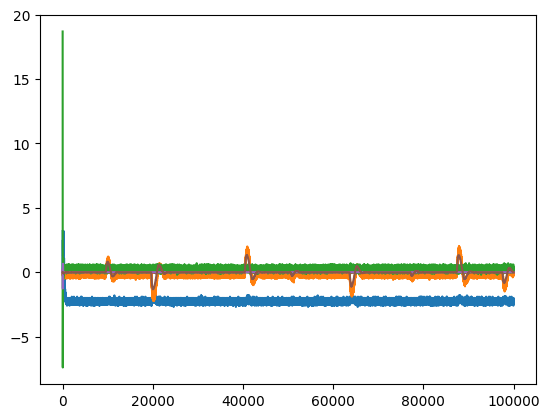

In [ ]:
# imu = imu.to_numpy()
plt.plot((imu+np.array([0, 0, 9.8, 0, 0, 0]))*10)

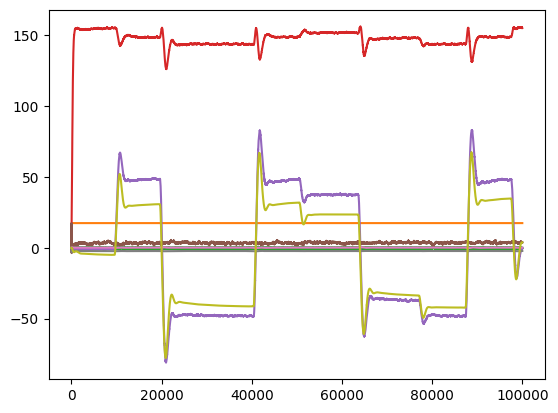

In [ ]:
# plt.plot(velocity_data)
plt.plot(estimated_data*100)


In [ ]:
x_train = (imu+np.array([0, 0, 9.8, 0, 0, 0]))*10
x_train.to_numpy()
x_train.shape

(100000, 6)

In [ ]:
y_train = 100*(estimated_data)
y_train.shape

(100000, 9)

In [ ]:
# function make x train data with 10 sequence
def make_x_train(x_train, x_train1, sequence_length):
    x_result = []
    x_result1 = []
    for index in range(len(x_train) - sequence_length):
        x_result.append(x_train[index: index + sequence_length])
        x_result1.append(x_train1[index])
    return np.array(x_result), np.array(x_result1)

x_train, x_train1 = make_x_train(x_train, y_train, 10)
x_train.shape

(99990, 10, 6)

In [ ]:
x_train1.shape

(99990, 9)

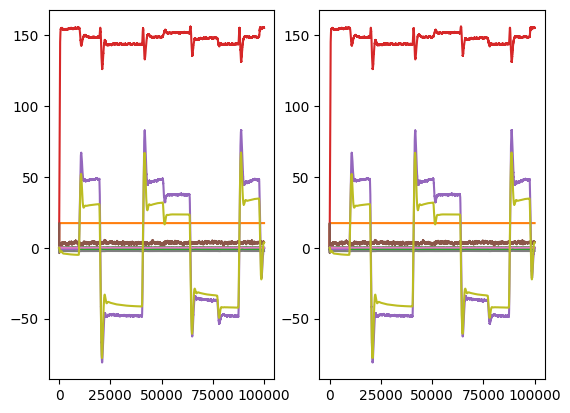

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(x_train1)
plt.subplot(1, 2, 2)
plt.plot(y_train)

ValueError: x and y can be no greater than 2D, but have shapes (99990,) and (99990, 10, 6)

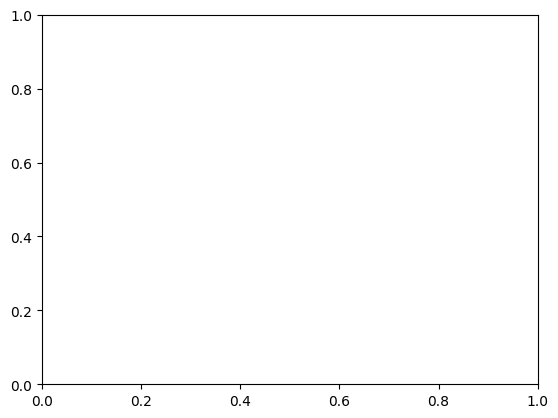

In [ ]:
plt.plot(x_train)

In [ ]:
## make tensorflow lstm model ##
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, Activation, concatenate, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers

In [ ]:
y_train.shape[1]

9

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 10, 6)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 9, 1)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 10, 32)         │          4,992 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_2 (LSTM)             │ (None, 9, 32)          │          4,352 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 10, 32)         │          8,320 │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_3 (LSTM)             │ (None, 9, 32)          │          8,320 │ lstm_2[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 19, 32)         │              0 │ lstm_1[0][0],          │
│                           │                        │                │ lstm_3[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 608)            │              0 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 32)             │         19,488 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 32)             │          1,056 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 9)              │            297 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 46,825 (182.91 KB)

 Trainable params: 46,825 (182.91 KB)

 Non-trainable params: 0 (0.00 B)

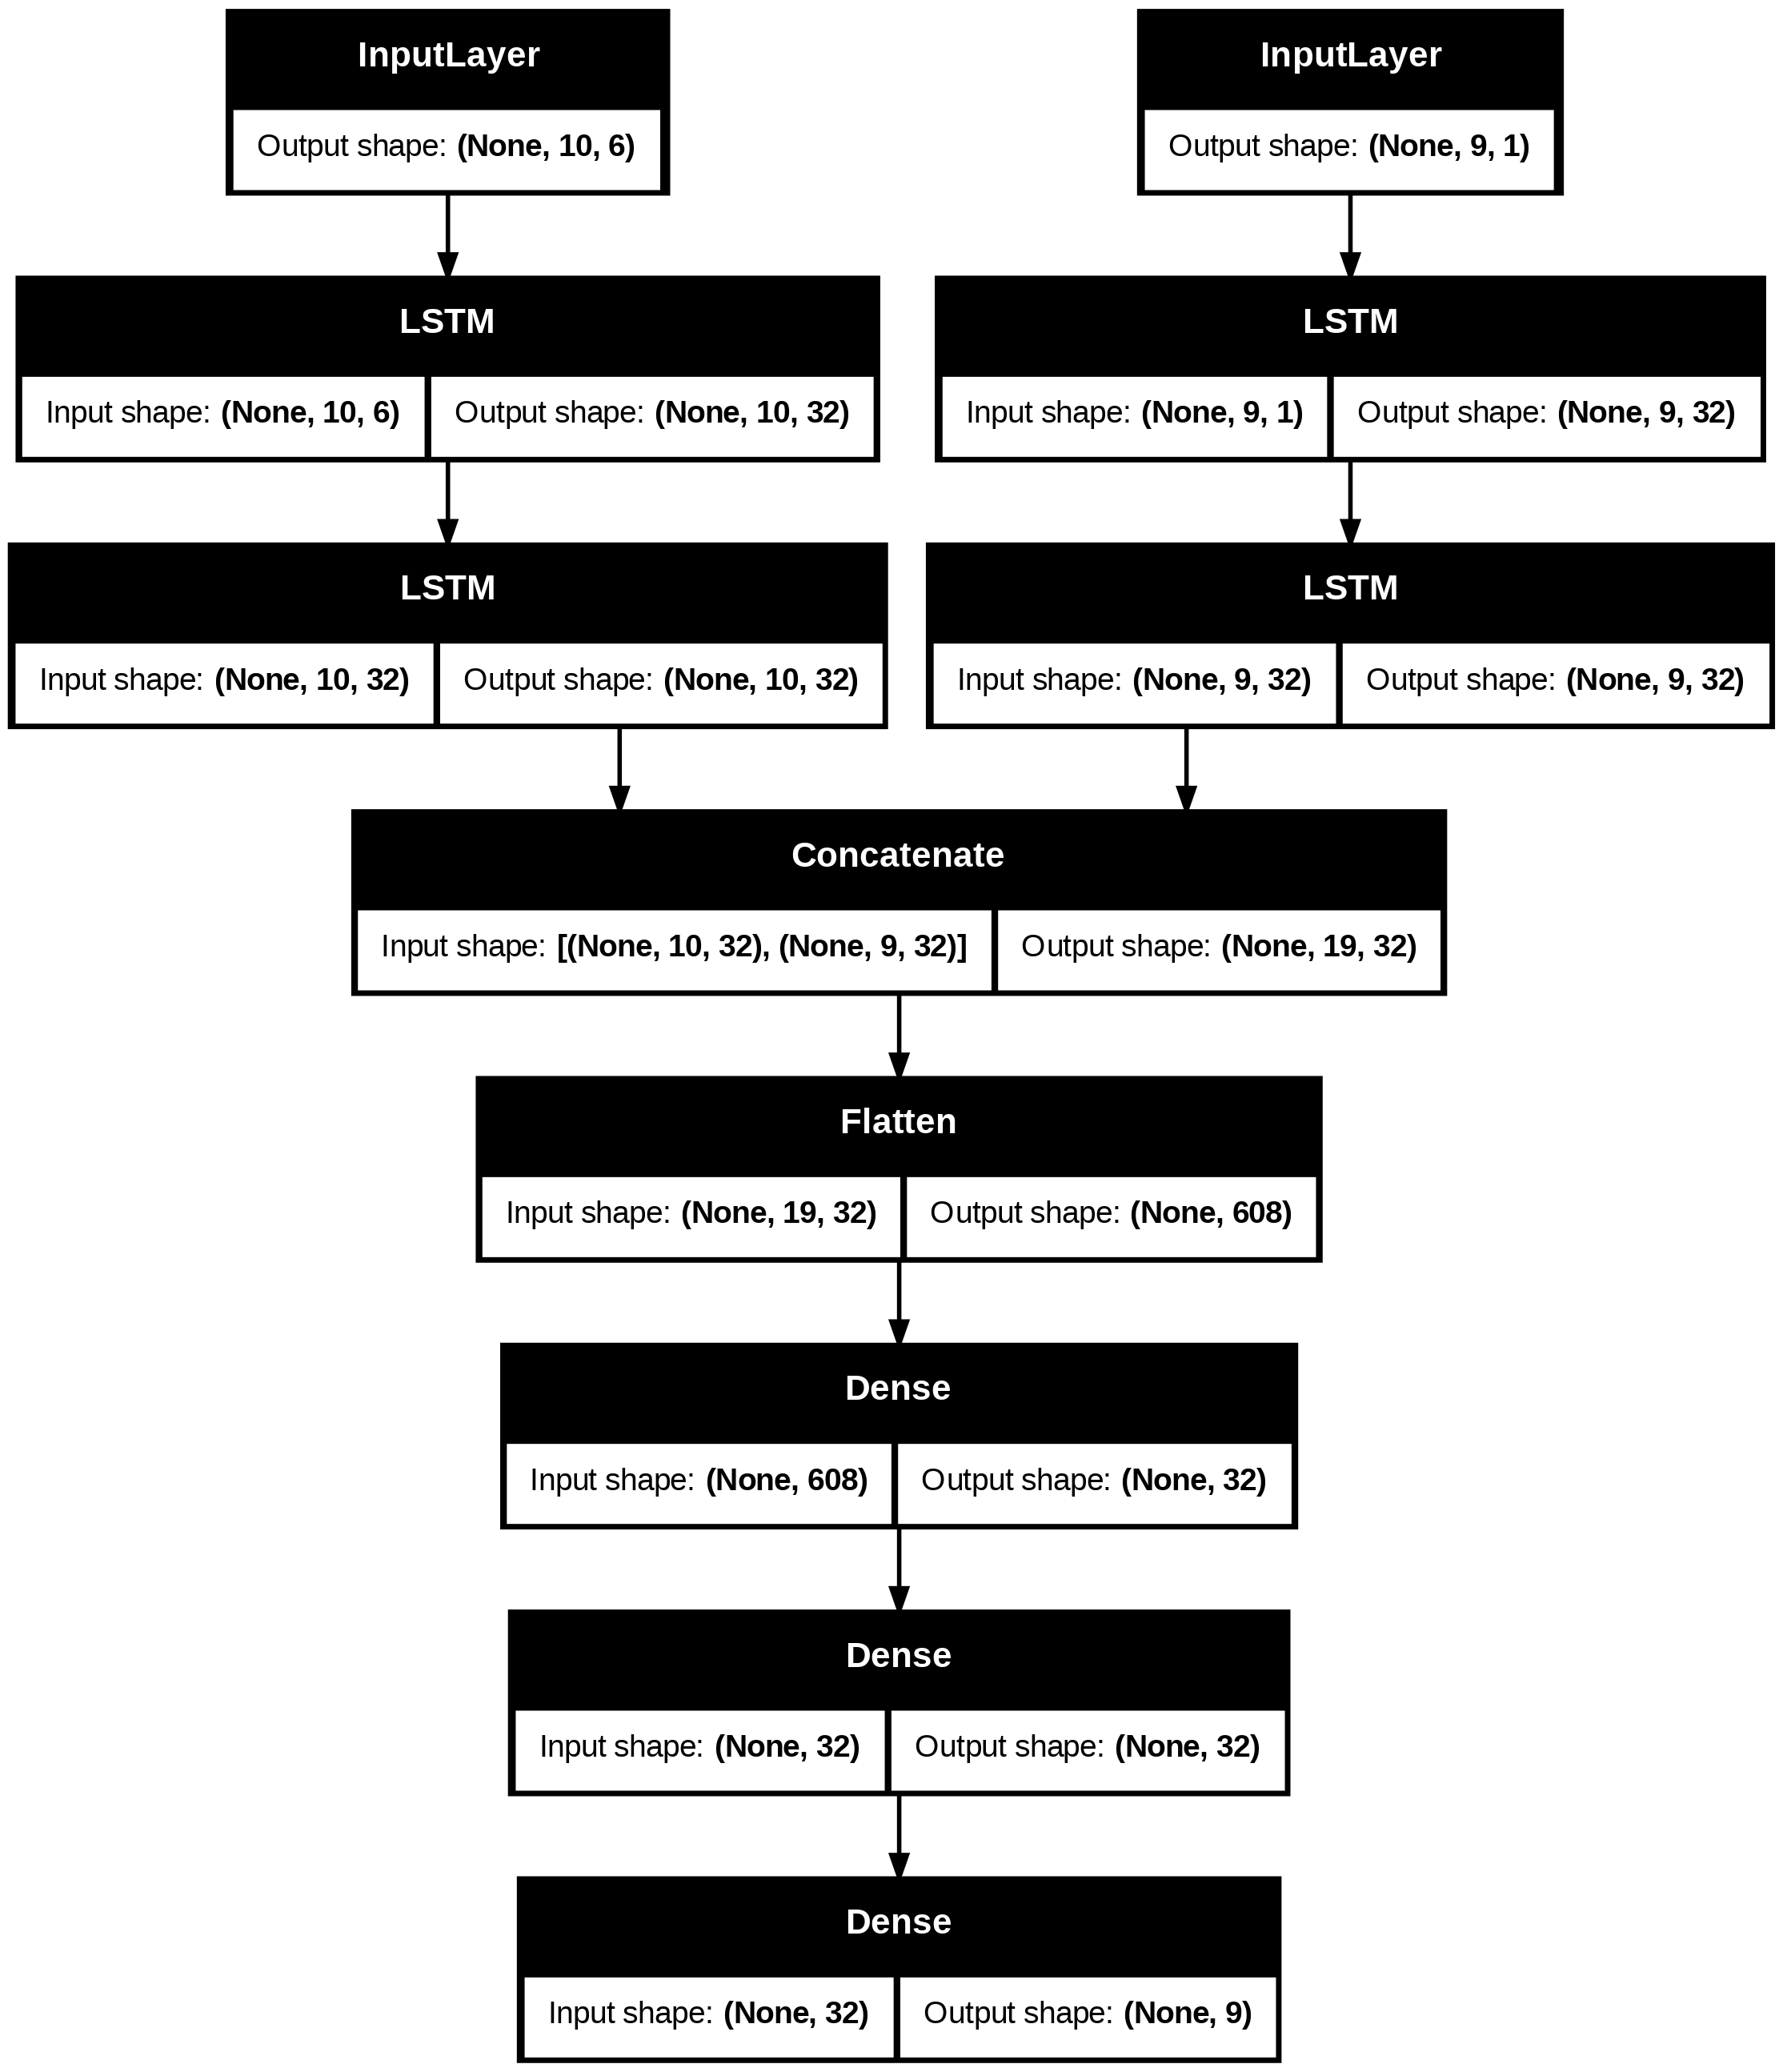

In [ ]:
# net work with two different input
def lstm_model(x_train, x_train1, y_train):
    input_1 = Input(shape=(x_train.shape[1], x_train.shape[2]))
    input_2 = Input(shape=(x_train1.shape[1], 1))

    lstm_1 = LSTM(32, return_sequences=True)(input_1)
    lstm_1 = LSTM(32, return_sequences=True)(lstm_1)

    lstm_2 = LSTM(32, return_sequences=True)(input_2)
    lstm_2 = LSTM(32, return_sequences=True)(lstm_2)

    lstm_3 = concatenate([lstm_1, lstm_2], axis=1)
    # output to one dimension
    lstm_3 = layers.Flatten()(lstm_3)
    lstm_3 = Dense(32, activation='linear')(lstm_3)
    lstm_3 = Dense(32, activation='linear', kernel_regularizer=regularizers.l2(0.01))(lstm_3)

    lstm_3 = Dense(y_train.shape[1], activation='linear')(lstm_3)


    # return model
    return Model(inputs=[input_1, input_2], outputs=lstm_3)

# example
model = lstm_model(x_train, x_train1, y_train)
model.summary()
# plot model
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True)




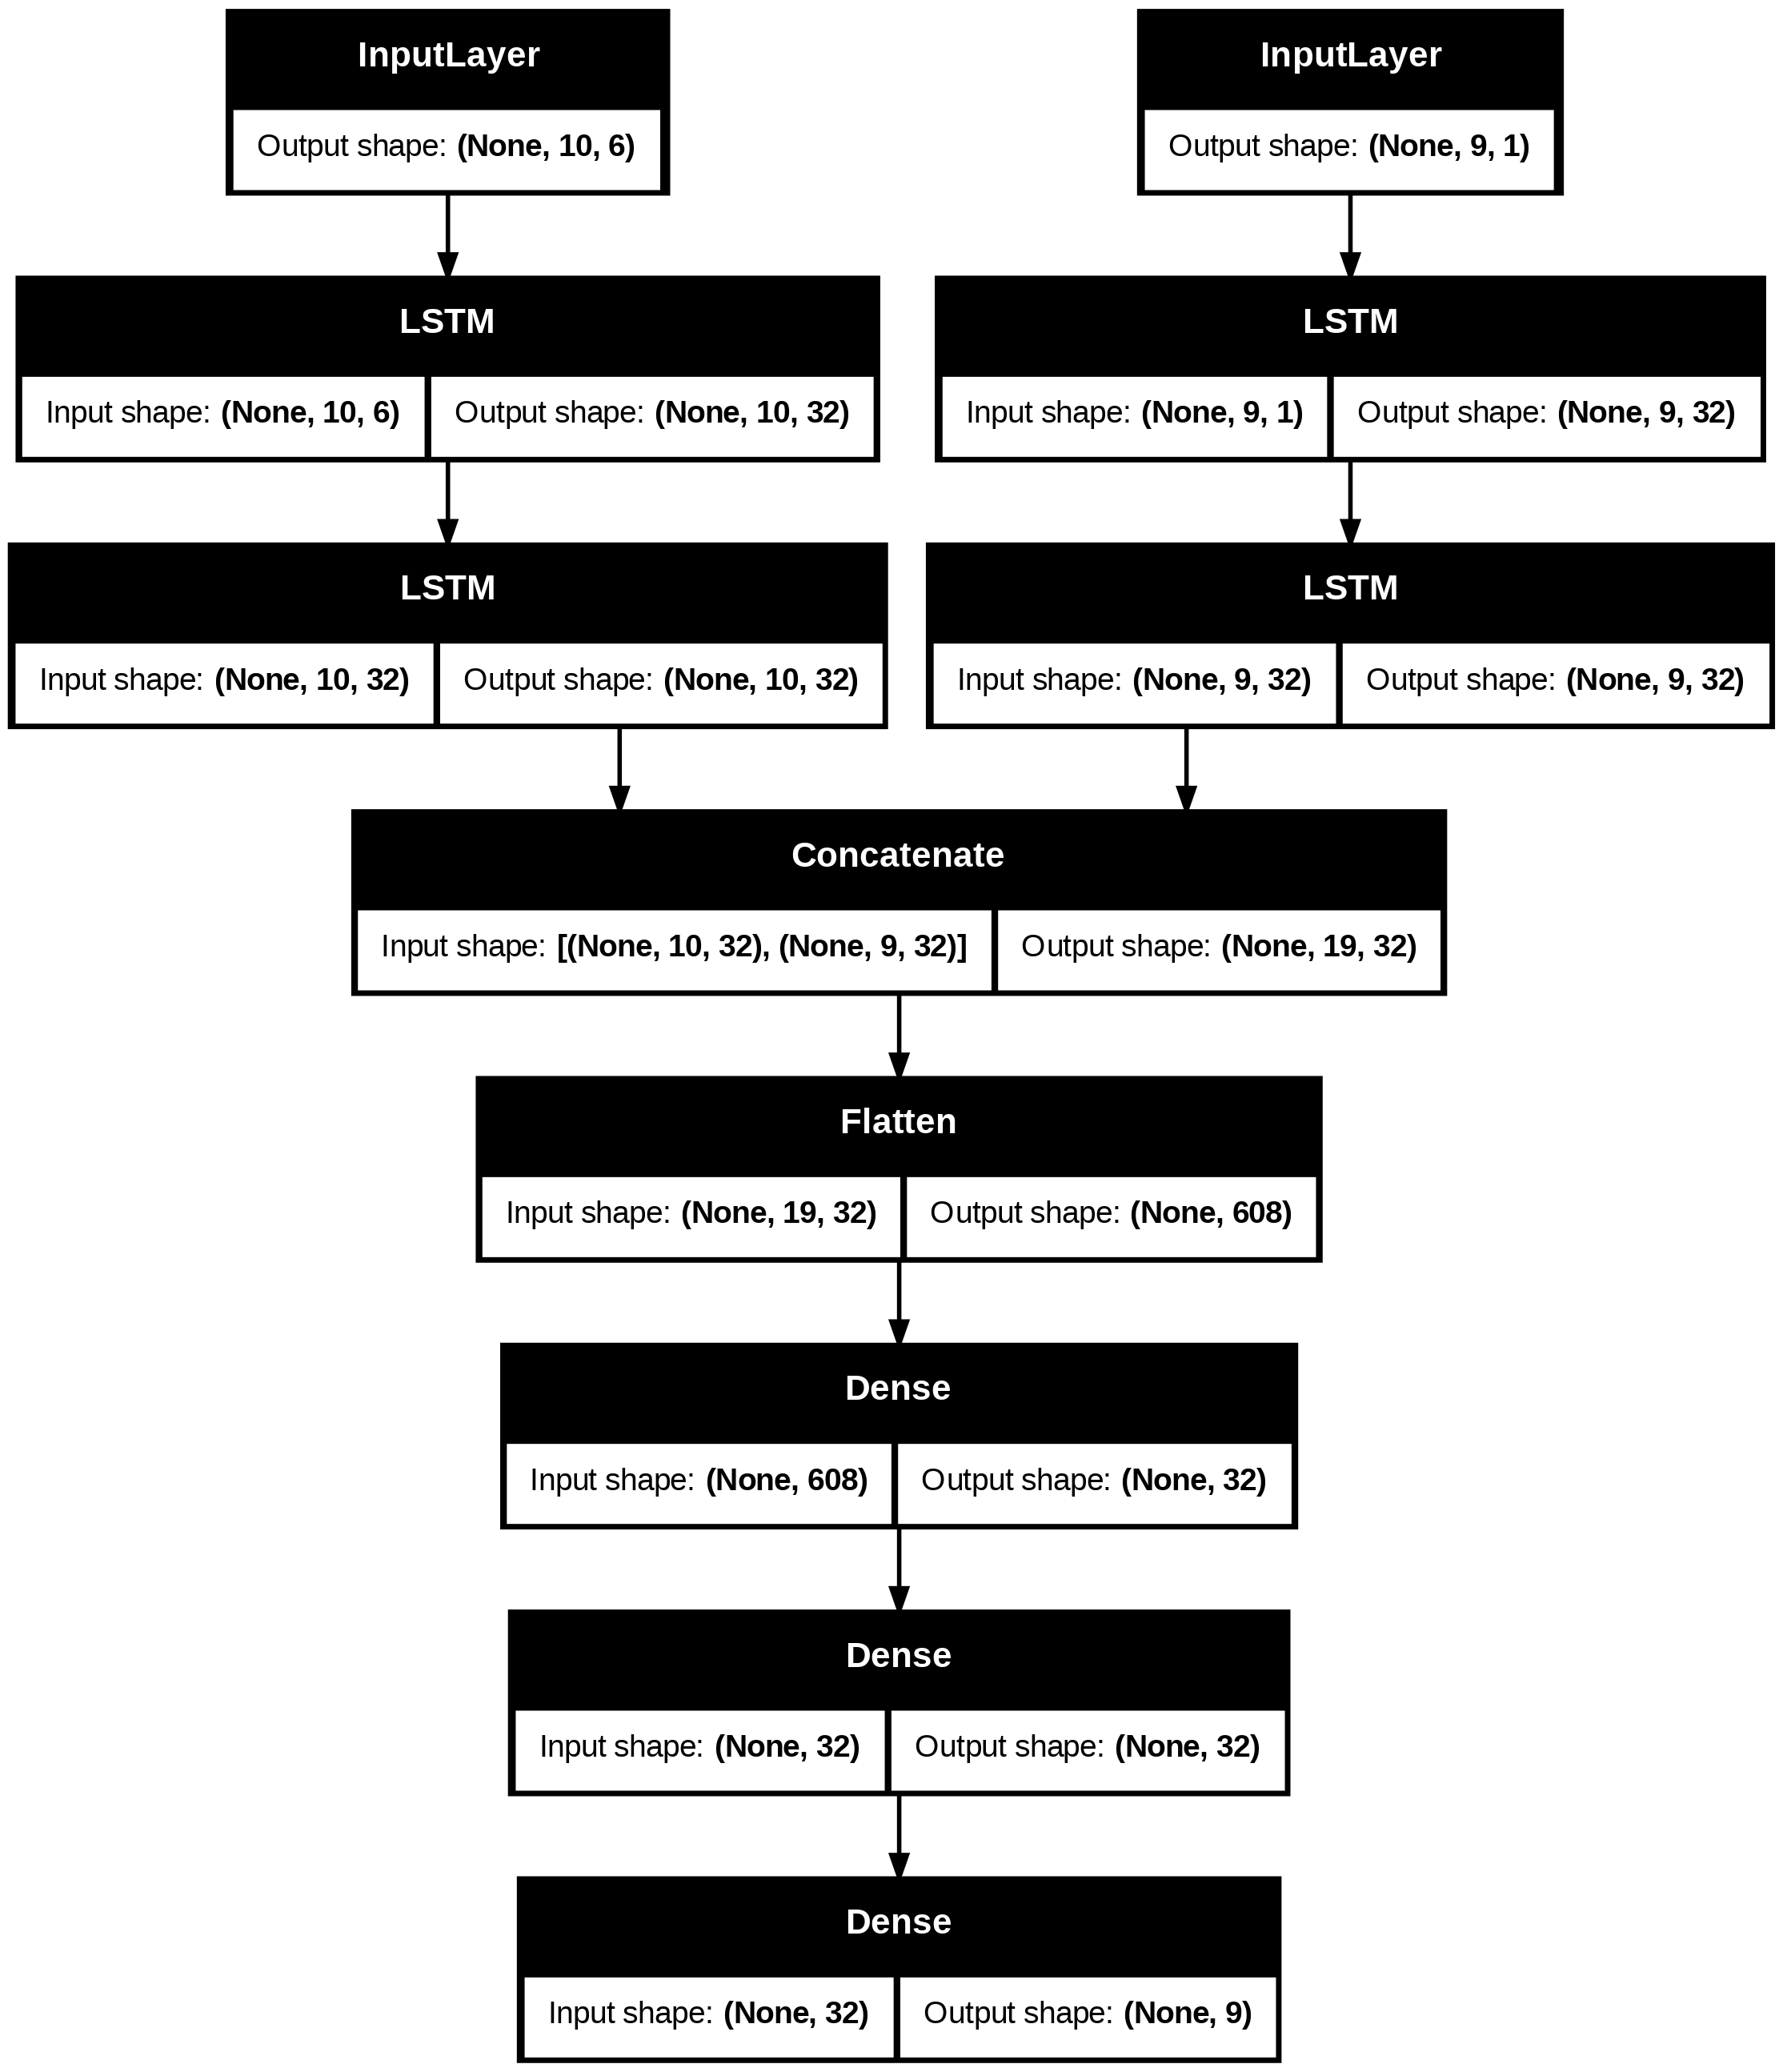

In [ ]:
# plot model
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True)

In [ ]:
# change datat to tensor #
x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
x_train1 = tf.convert_to_tensor(x_train1, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

# compile model
model.compile(loss='mse', optimizer='adam', metrics=['mse'])

# early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

# save model
model_path = 'model.h5'
# checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss', verbose=1, save_best_only=True)

# fit model
# history = model.fit([x_train, x_train1], y_train, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop, checkpoint])

In [ ]:
with tf.device('/device:GPU:0'):
    history = model.fit([x_train, x_train1], y_train, epochs=100, batch_size=128, validation_split=0.2)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 542.0778 - mse: 541.7213 - val_loss: 2.5218 - val_mse: 2.1419
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.9657 - mse: 1.5858 - val_loss: 1.8498 - val_mse: 1.4709
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 1.3642 - mse: 0.9861 - val_loss: 1.7700 - val_mse: 1.3948
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1.1066 - mse: 0.7326 - val_loss: 1.5210 - val_mse: 1.1509
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.8662 - mse: 0.4977 - val_loss: 1.1861 - val_mse: 0.8236
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.7843 - mse: 0.4243 - val_loss: 1.2042 - val_mse: 0.8525
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.7023 - mse: 0.3537 - val_loss: 1.2700 - val_mse: 0.9317
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6480 - mse: 0.3134 - val_loss: 1.3566 - val_mse: 1.0335
Epoch 9/100
625/625 ━━━━━━━━━━━━━━

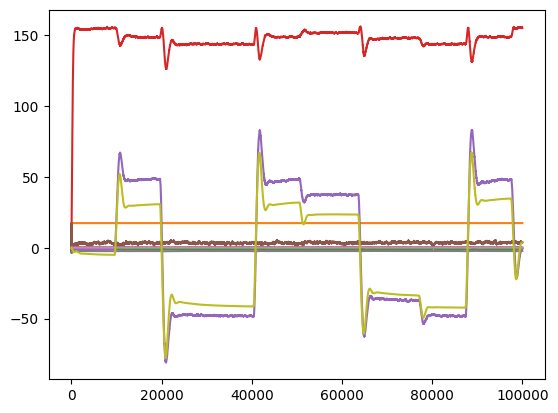

In [ ]:
plt.plot(y_train)
plt.show()

In [ ]:
# save model #
model.save('LSTM_error_NN_model_new_strcut_two_input')

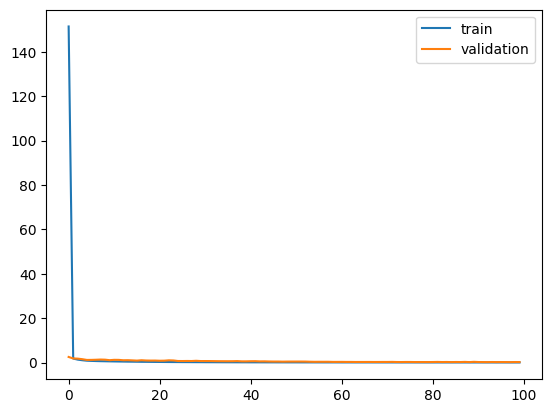

In [ ]:
# plot loss #
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()
# save history as csv
pd.DataFrame(history.history).to_csv('history.csv')

In [ ]:
# predict #
# y_pred = scaler_y.inverse_transform(y_pred)
predicted_data = model.predict([x_train, x_train1])

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step


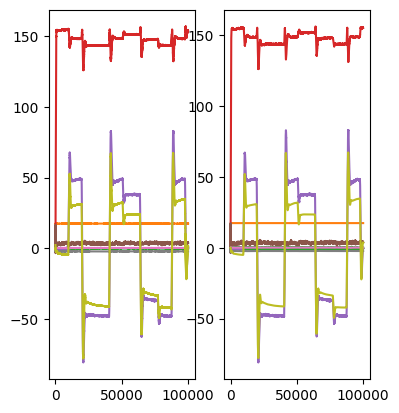

In [ ]:
# plot prediction #
plt.subplot(1, 3, 1)
plt.plot(predicted_data, label='real')
plt.subplot(1, 3, 2)
plt.plot(y_train, label='prediction')

In [ ]:
!git config --global user.email "alibaniasad1999@gmail.com"
!git config --global user.name "Ali"
!git status
!git add -A
!git commit -m 'sigmoid relu lstm error 3 output model from colab in new input and new struct two input'
!git push

In [ ]:
%cd otter-USV

In [ ]:
from google.colab import files
%ls

In [ ]:
files.download('LSTM_error_NN_model')